In [18]:
from pathlib import Path

from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver

In [19]:
load_dotenv()

True

In [20]:
generator_endpoint = HuggingFaceEndpoint(
    repo_id="Qwen/Qwen2.5-72B-Instruct",  # Updated to use provider-supported Llama model
    task="text-generation",
)

model = ChatHuggingFace(llm=generator_endpoint)

In [21]:
class JokeState(TypedDict):
    topic: str
    joke: str
    explanation: str

In [22]:
def generate_joke(state: JokeState):
    prompt = f"Write a short joke about {state['topic']}"
    response = model.invoke(prompt).content
    return {'joke': response}


In [23]:
def generate_explanation(state: JokeState):
    prompt = f"Explain this joke in simple terms: {state['joke']}"
    response = model.invoke(prompt).content
    return {'explanation': response}


In [24]:
graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

In [25]:
checkpointer = InMemorySaver()
workflow = graph.compile(checkpointer=checkpointer)

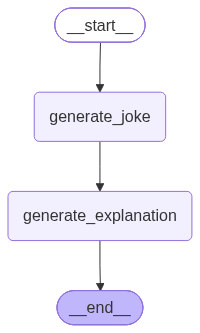

In [26]:
workflow

In [27]:
config1 = {"configurable": {"thread_id": "1"}}

initial_state = {
    'topic':'pizza'
}

workflow.invoke(initial_state, config=config1)

{'topic': 'pizza',
 'joke': 'Why did the pizza go to the doctor? Because it was feeling a little saucy!',
 'explanation': 'This joke plays on the double meaning of the word "saucy." \n\n1. **Saucy (food meaning)**: When something is "saucy," it can mean that it has a lot of sauce on it. Pizzas are often covered in tomato sauce.\n2. **Saucy (behavior meaning)**: When someone is "saucy," it can mean they are playful, flirtatious, or a bit cheeky.\n\nIn the joke, the pizza goes to the doctor because it\'s "feeling a little saucy." The humor comes from the unexpected twist of using "saucy" to mean both having a lot of sauce and being a bit playful or cheeky. It\'s a silly pun that makes people laugh because it\'s a playful way to describe a pizza!'}

In [28]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to the doctor? Because it was feeling a little saucy!', 'explanation': 'This joke plays on the double meaning of the word "saucy." \n\n1. **Saucy (food meaning)**: When something is "saucy," it can mean that it has a lot of sauce on it. Pizzas are often covered in tomato sauce.\n2. **Saucy (behavior meaning)**: When someone is "saucy," it can mean they are playful, flirtatious, or a bit cheeky.\n\nIn the joke, the pizza goes to the doctor because it\'s "feeling a little saucy." The humor comes from the unexpected twist of using "saucy" to mean both having a lot of sauce and being a bit playful or cheeky. It\'s a silly pun that makes people laugh because it\'s a playful way to describe a pizza!'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1b3f88-8343-6e4c-8002-71bee608b00f'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-09-19T07:05:44.35824

In [29]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to the doctor? Because it was feeling a little saucy!', 'explanation': 'This joke plays on the double meaning of the word "saucy." \n\n1. **Saucy (food meaning)**: When something is "saucy," it can mean that it has a lot of sauce on it. Pizzas are often covered in tomato sauce.\n2. **Saucy (behavior meaning)**: When someone is "saucy," it can mean they are playful, flirtatious, or a bit cheeky.\n\nIn the joke, the pizza goes to the doctor because it\'s "feeling a little saucy." The humor comes from the unexpected twist of using "saucy" to mean both having a lot of sauce and being a bit playful or cheeky. It\'s a silly pun that makes people laugh because it\'s a playful way to describe a pizza!'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1b3f88-8343-6e4c-8002-71bee608b00f'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-09-19T07:05:44.3582

FOR THREAD_2 -> same flow and maintains a diffent history

In [39]:
config_2 = {"configurable":{"thread_id":"2"}}

In [40]:
input_ = {"topic":"biryani"}

In [41]:
workflow.invoke(input_,config=config_2)

{'topic': 'biryani',
 'joke': 'Why did the biryani go to the doctor?\n\nBecause it was feeling a little rice-y!',
 'explanation': 'The joke is a play on words. Biryani is a type of rice dish. When something feels "queasy," it means it\'s feeling sick or unwell. In this joke, the biryani is feeling "rice-y," which sounds like "queasy." So, the biryani went to the doctor because it was feeling a bit sick, but with a funny twist using the word "rice-y" to match the rice in the dish.'}

TIME TRAVEL

In [32]:
config2 = {"configurable": {"thread_id": "1","checkpoint_id": "1f1b3f88-20c0-6bbc-8000-02644168038f"}}
workflow.get_state(config2)

StateSnapshot(values={'topic': 'pizza'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f1b3f88-20c0-6bbc-8000-02644168038f'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-09-19T07:05:34.028480+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1b3f88-20bd-661a-bfff-acbcb1c6a316'}}, tasks=(PregelTask(id='346a9487-9804-3f40-80cc-e713483070ff', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result={'joke': 'Why did the pizza go to the doctor? Because it was feeling a little saucy!'}),), interrupts=())

i can debug or invoke the workflow from the particular checkpoint,
as you see we are taking the checkpoint as from topic and going to next = generation joke on topic

In [33]:
workflow.invoke(None,config2) 

{'topic': 'pizza',
 'joke': "Why don't scientists trust atoms anymore? Because they make up everything, but that's not the pizza joke you wanted, is it?\n\nHere's a pizza joke for you:\nWhy did the pizza go to the doctor?\nBecause it was feeling a little saucy!",
 'explanation': 'Sure, let\'s break down both jokes!\n\n### Joke 1: The Atom Joke\n**Joke:** Why don\'t scientists trust atoms anymore? Because they make up everything, but that\'s not the pizza joke you wanted, is it?\n\n**Explanation:**\n- ** atoms make up everything:** Atoms are the basic building blocks of all matter. Everything in the universe is made up of atoms.\n- ** scientists don\'t trust atoms:** This is a play on words. "Make up" can mean both "compose" (as in atoms composing everything) and "fabricate" (as in lying or not being trustworthy). The joke suggests that atoms are untrustworthy because they "make up" everything, playing on the double meaning of "make up."\n\n### Joke 2: The Pizza Joke\n**Joke:** Why did 

In [ ]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to the doctor? Because it was feeling a little saucy!', 'explanation': 'This joke is playing with words. "Saucy" can mean two things:\n\n1. Having a lot of sauce, which a pizza has.\n2. Being a bit cheeky or mischievous.\n\nThe joke is saying the pizza went to the doctor because it was feeling "saucy," which makes you think about the pizza having too much sauce. But the funny part is that it also sounds like the pizza is being a little bit cheeky or naughty!'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1b3f10-d310-6e34-8003-b6a1ca024662'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-09-19T06:12:11.500472+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1b3f10-ab5d-6e64-8002-c4bd31ad4aaf'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to

UPDATE_STATE

In [ ]:
update_config = {"configurable":{"thread_id":"1","checkpoint_id":"1f1b3f88-20c0-6bbc-8000-02644168038f"}}

In [38]:
workflow.invoke({"topic": "samosa"},update_config)

{'topic': 'samosa',
 'joke': 'Why did the samosa go to the doctor?\n\nBecause it was feeling a little *stuffed*!',
 'explanation': 'The joke is a play on words. A samosa is a type of food that is usually filled with ingredients, making it "stuffed." In the joke, the samosa is personified and is said to go to the doctor because it is feeling "stuffed," which means it feels full or overly filled, just like how a person might feel after eating too much. The humor comes from the double meaning of the word "stuffed."'}

In [42]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'samosa', 'joke': 'Why did the samosa go to the doctor?\n\nBecause it was feeling a little *stuffed*!', 'explanation': 'The joke is a play on words. A samosa is a type of food that is usually filled with ingredients, making it "stuffed." In the joke, the samosa is personified and is said to go to the doctor because it is feeling "stuffed," which means it feels full or overly filled, just like how a person might feel after eating too much. The humor comes from the double meaning of the word "stuffed."'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1b3fa0-231f-61a2-8004-c454a6a9e311'}}, metadata={'source': 'loop', 'step': 4, 'parents': {}, 'topic': 'samosa'}, created_at='2026-09-19T07:16:18.521916+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1b3f9e-cb0a-6148-8003-4fccf109e86b'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'topic': 'samosa', 'joke': 